In [2]:
import numpy as np

from scripts.data_loader import load_dataframe
from scripts.utils import NETWORK_TYPE

filename = "5G_data_2023.mat"

# Series of random seeds for reproducability
random_seeds = np.loadtxt('../data/random_seeds.csv', dtype=int)

# load the dataframe from saved file or 'raw' matlab file
df = load_dataframe(filename, NETWORK_TYPE._5G)

# # Drop unused columns to save space
matrix_cols_to_drop = ['toa_pps', 'toa_cir', 'toa_cov', 'campaign_id']
df['measurements_matrix'] = df['measurements_matrix'].apply(
    lambda x: x.drop(columns=matrix_cols_to_drop)
)

print(f"Loaded df of size {df.shape}")

df.info

Loaded dataframe from .h5 file: /Users/andreres/Documents/UIO/master/thesis/dev/5G_localization/data/dataframe_cache/5G_data_2023.h5
Loaded df of size (33537, 4)


<bound method DataFrame.info of              lat        lng  \
0      41.898338  12.429556   
1      41.898337  12.429557   
2      41.898336  12.429557   
3      41.898335  12.429556   
4      41.898334  12.429555   
...          ...        ...   
33532  41.898398  12.429511   
33533  41.898396  12.429512   
33534  41.898388  12.429512   
33535  41.898383  12.429513   
33536  41.898380  12.429514   

                                     measurements_matrix  campaign_id  
0           pci  beam_index  nr_arfcn  operator_id   ...            1  
1           pci  beam_index  nr_arfcn  operator_id   ...            1  
2           pci  beam_index  nr_arfcn  operator_id   ...            1  
3           pci  beam_index  nr_arfcn  operator_id   ...            1  
4           pci  beam_index  nr_arfcn  operator_id   ...            1  
...                                                  ...          ...  
33532       pci  beam_index  nr_arfcn  operator_id   ...           79  
33533       pci  be

In [3]:
import pandas as pd


def count_frequencies(df: pd.DataFrame) -> dict:
    return {name: dict(group['nr_arfcn'].value_counts()) for name, group in df.groupby('operator_id')}


df['counts'] = df['measurements_matrix'].apply(count_frequencies)

agg = {}
# Iterate through each row's counts
for _, row in df.iterrows():
    counts_dict = row['counts']

    # For each operator in the counts dictionary
    for operator_id, nr_arfcn_counts in counts_dict.items():
        # Initialize the operator in the agg dict if it doesn't exist
        if operator_id not in agg:
            agg[operator_id] = {}

        # For each nr_arfcn and its count
        for nr_arfcn, count in nr_arfcn_counts.items():
            # Convert numpy.int64 to regular int if needed
            count_value = int(count) if hasattr(count, 'item') else count

            # Add to existing count or initialize
            if nr_arfcn in agg[operator_id]:
                agg[operator_id][nr_arfcn] += count_value
            else:
                agg[operator_id][nr_arfcn] = count_value

agg

{1: {648768: 216244},
 10: {643296: 1534636,
  643295: 509674,
  432050: 127375,
  432049: 62031,
  432051: 41062,
  156030: 17850},
 50: {641664: 755048, 152690: 224597, 152691: 87812, 641663: 5732},
 88: {638016: 1119185, 638015: 318874, 368890: 256008, 535010: 4754}}

In [4]:
from scripts.utils import get_config

aggregated_df = pd.DataFrame(agg)

aggregated_df

frequency_map = get_config("frequency_map.json")

color_map = get_config("color_map.json", "operatorId")

color_map = {int(k): v for k, v in color_map.items()}

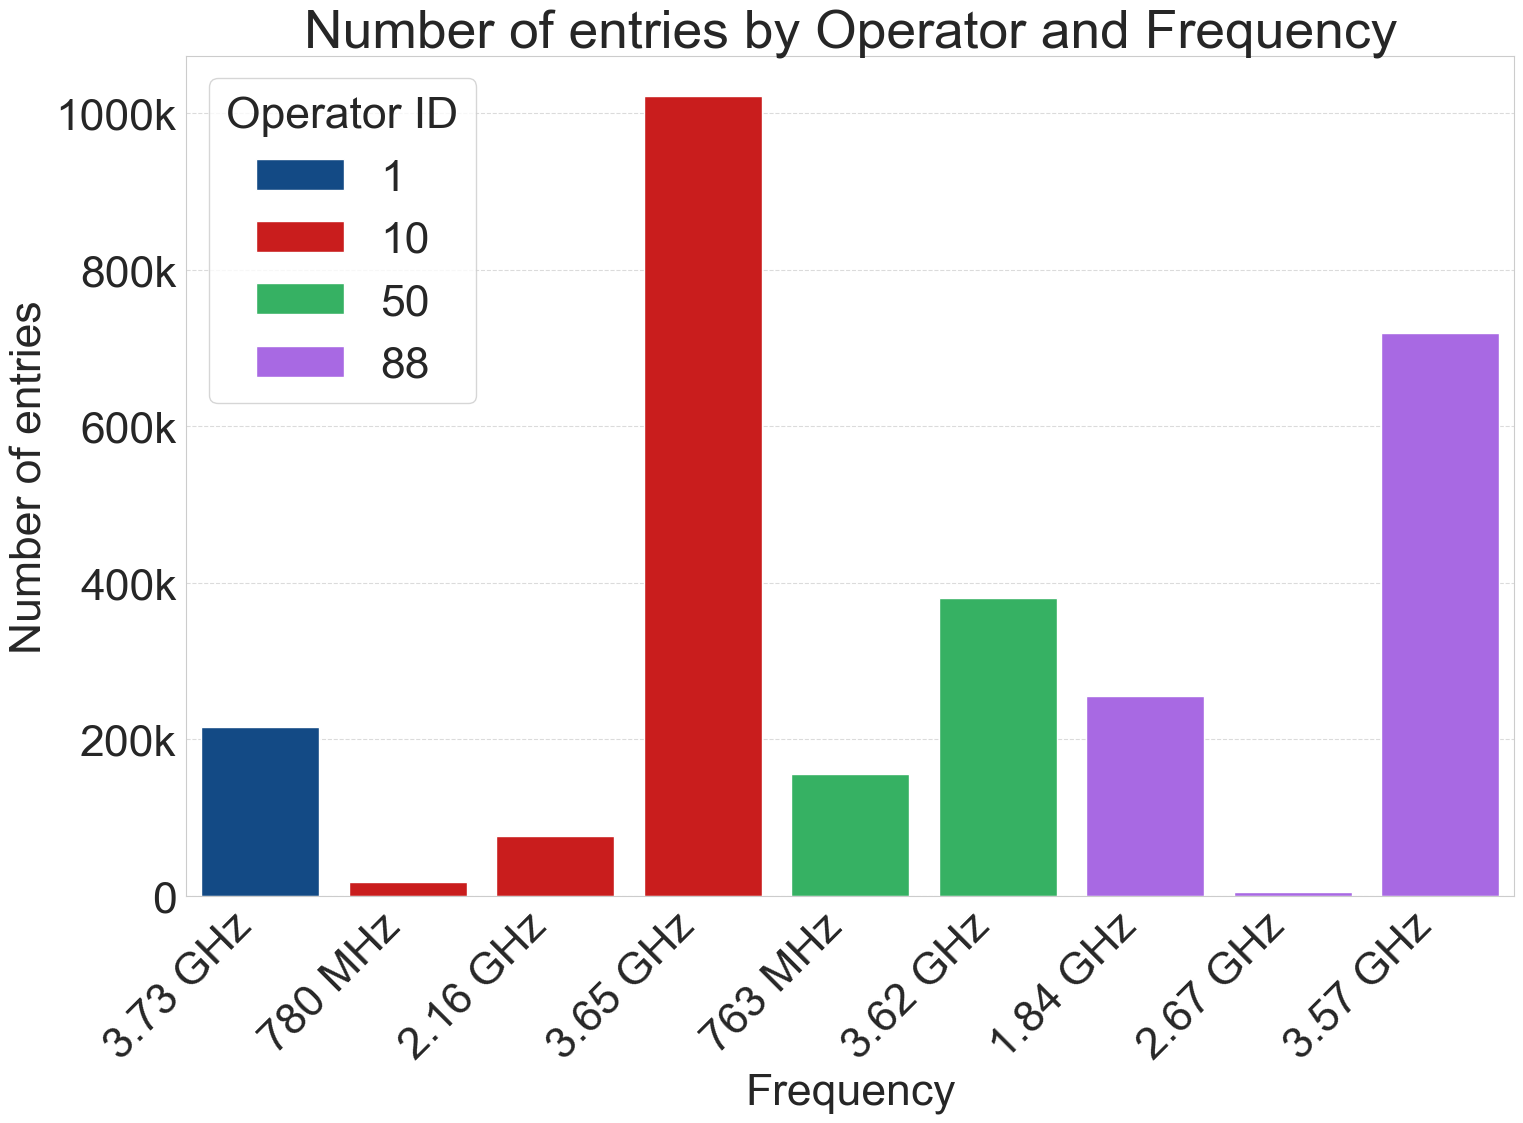

,nr_arfcn,operator_id,count,frequency,frequency_label,arfcn_freq
0,648768,1,216244.0,3731,3.73 GHz,3.73 GHz
21,156030,10,17850.0,780,780 MHz,780 MHz
18,432050,10,127375.0,2160,2.16 GHz,2.16 GHz
19,432049,10,62031.0,2160,2.16 GHz,2.16 GHz
20,432051,10,41062.0,2160,2.16 GHz,2.16 GHz
16,643296,10,1534636.0,3649,3.65 GHz,3.65 GHz
17,643295,10,509674.0,3649,3.65 GHz,3.65 GHz
38,152690,50,224597.0,763,763 MHz,763 MHz
39,152691,50,87812.0,763,763 MHz,763 MHz
37,641664,50,755048.0,3624,3.62 GHz,3.62 GHz


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.rcParams.update(
    {
        "font.size": 32,  # Default text size
    }
)

# Convert frequency_map from string keys to integer keys for easier mapping
frequency_map_int = {}
for op_id_str, arfcn_dict in frequency_map.items():
    op_id = int(op_id_str)
    frequency_map_int[op_id] = {int(arfcn): freq for arfcn, freq in arfcn_dict.items()}

# Reset index to make nr_arfcn a column
df_reset = aggregated_df.reset_index()
df_reset.rename(columns={'index': 'nr_arfcn'}, inplace=True)

# Melt the DataFrame to long format
df_melted = pd.melt(df_reset, id_vars=['nr_arfcn'],
                    value_vars=aggregated_df.columns,
                    var_name='operator_id', value_name='count')

# Drop rows with NaN counts
df_melted = df_melted.dropna()


# Add frequency column based on the mapping
def get_frequency(row):
    op_id = row['operator_id']
    arfcn = row['nr_arfcn']
    try:
        return frequency_map_int[op_id][arfcn]
    except (KeyError, TypeError):
        return None


df_melted['frequency'] = df_melted.apply(get_frequency, axis=1)


# Format frequency labels (MHz/GHz)
def format_frequency(freq):
    if freq is None:
        return 'Unknown'
    elif freq >= 1000:
        return f"{freq / 1000:.2f} GHz"
    else:
        return f"{freq} MHz"


df_melted['frequency_label'] = df_melted['frequency'].apply(format_frequency)

# Create a new column combining nr_arfcn and frequency for x-axis labels
df_melted['arfcn_freq'] = df_melted['frequency_label']

# Sort the DataFrame by operator_id and frequency (ascending)
df_melted = df_melted.sort_values(['operator_id', 'frequency'])

operators = sorted(df_melted['operator_id'].unique())
custom_palette = {op: color_map[op] for op in operators}

# Create the plot
plt.figure(figsize=(16, 12))

# Use order parameter to control the order of categories on the x-axis
# This preserves the grouping by operator but sorts by frequency within each group
sns.barplot(x='arfcn_freq', y='count', hue='operator_id',
            data=df_melted,
            palette=custom_palette,
            order=df_melted['arfcn_freq'],
            errorbar=None
            )

# Customize the plot
plt.title('Number of entries by Operator and Frequency')
plt.xlabel('Frequency')
plt.ylabel('Number of entries')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Operator ID')

# Format y-axis to display large numbers better
plt.ticklabel_format(style='plain', axis='y')

from matplotlib.ticker import FuncFormatter


def format_thousands(x, pos):
    if x >= 1000:
        return f'{x / 1000:.0f}k'
    else:
        return f'{x:.0f}'


plt.gca().yaxis.set_major_formatter(FuncFormatter(format_thousands))

# Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tight layout to ensure everything fits
plt.tight_layout()

# Show the plot
plt.show()

df_melted


In [9]:
highs = df_melted[df_melted['frequency'] > 3500]

highs = highs['count'].sum()
total = df_melted['count'].sum()
print(f'{highs} of {total} high frequencies ( {highs / total * 100:.2f}% )')

4459393.0 of 5280882.0 high frequencies ( 84.44% )
